<a href="https://colab.research.google.com/github/Malek720/MachineLearning/blob/EMPLOYMENT/EMPLOYMENT_MAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv(
    "/content/adult.data",
    header=None,
    skipinitialspace=True
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,1


In [ ]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df.columns = columns

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 32561
Number of columns: 15


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Target

In [ ]:
df["workclass"].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


"?" les vals manquantes

---



In [ ]:
(df == "?").sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,7
relationship,0
race,0
sex,0


 Missing values

In [ ]:
df = df.replace("?", np.nan)

print("Missing values converted to NaN.")

Missing values converted to NaN.


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
marital-status        0
occupation            7
relationship          0
race                  0
sex                   0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      556
income                0
workclass_binary      0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

display(missing_percentage)

,0
native-country,1.809601
occupation,0.022783
fnlwgt,0.000000
age,0.000000
education,0.000000
education-num,0.000000
marital-status,0.000000
workclass,0.000000
relationship,0.000000
race,0.000000


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

display(missing_percentage)

,0
native-country,1.809601
occupation,0.022783
fnlwgt,0.000000
age,0.000000
education,0.000000
education-num,0.000000
marital-status,0.000000
workclass,0.000000
relationship,0.000000
race,0.000000


Check duplicate rows

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 24


In [ ]:
if duplicate_count > 0:
    df = df.drop_duplicates().copy()

print("New dataset shape:", df.shape)

New dataset shape: (30701, 16)


NETTOYAGE DE LA VARIABLE CIBLE

In [ ]:
df = df.dropna(subset=["workclass"]).copy()

print("Missing workclass values:")
print(df["workclass"].isnull().sum())

print("New dataset shape:")
print(df.shape)

Missing workclass values:
0
New dataset shape:
(30701, 16)


VISUALISATION DE WORKCLASS

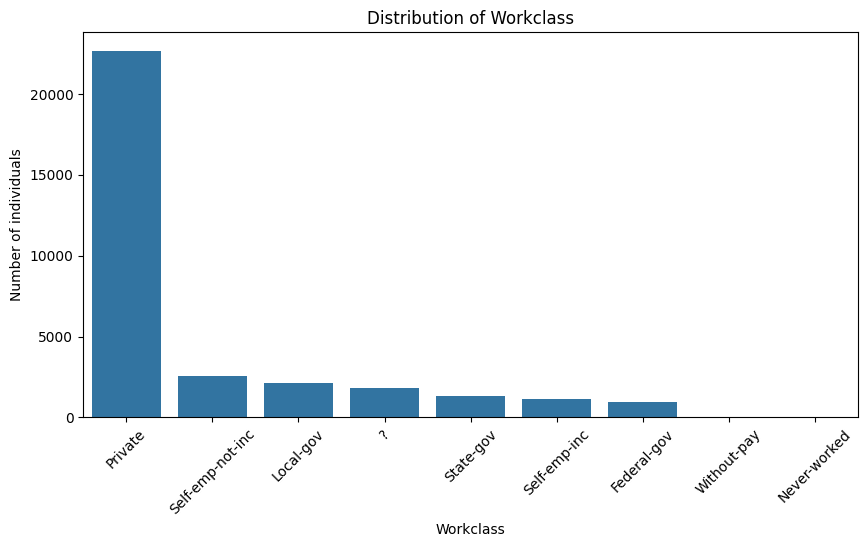

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="workclass",
    order=df["workclass"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Workclass")
plt.xlabel("Workclass")
plt.ylabel("Number of individuals")
plt.show()

In [ ]:
df = df[df["workclass"] != "?"].copy()

In [ ]:
df["workclass"].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df["workclass_binary"] = (
    df["workclass"] == "Private"
).astype(int)

In [ ]:
df["workclass_binary"].value_counts()

,count
workclass_binary,
1,22696
0,8029


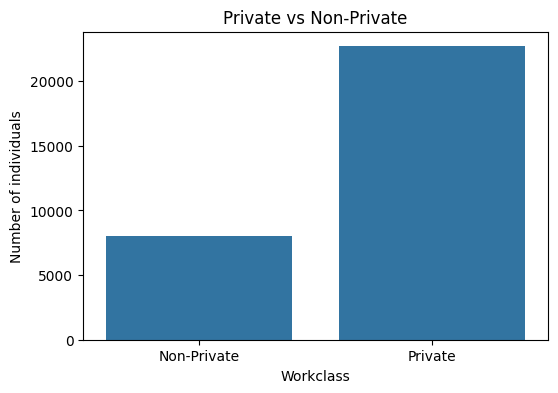

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="workclass_binary"
)

plt.title("Private vs Non-Private")
plt.xlabel("Workclass")
plt.ylabel("Number of individuals")

plt.xticks(
    [0, 1],
    ["Non-Private", "Private"]
)

plt.show()

 EDUCATION VS WORKCLASS

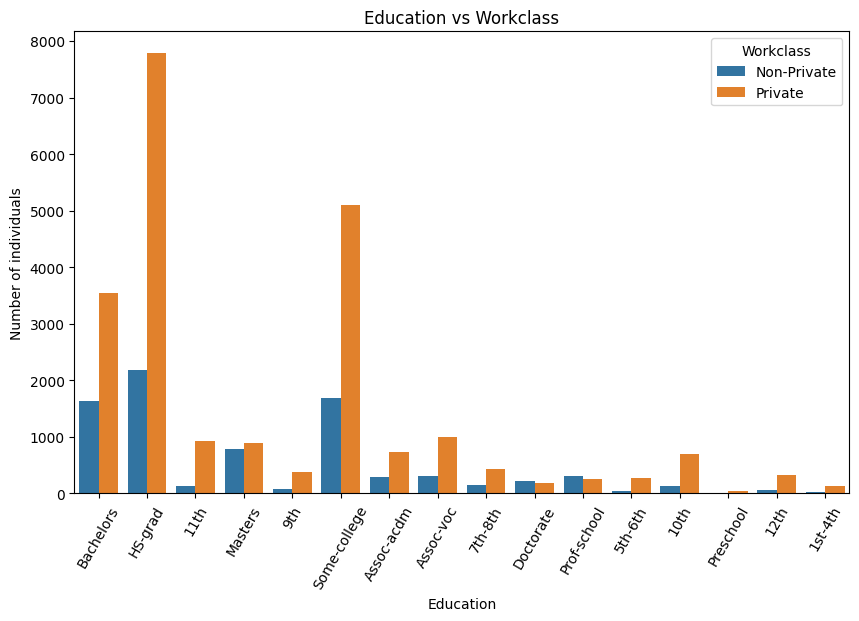

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="education",
    hue="workclass_binary"
)

plt.xticks(rotation=60)
plt.title("Education vs Workclass")
plt.xlabel("Education")
plt.ylabel("Number of individuals")

plt.legend(
    title="Workclass",
    labels=["Non-Private", "Private"]
)

plt.show()

Age vs Workclass

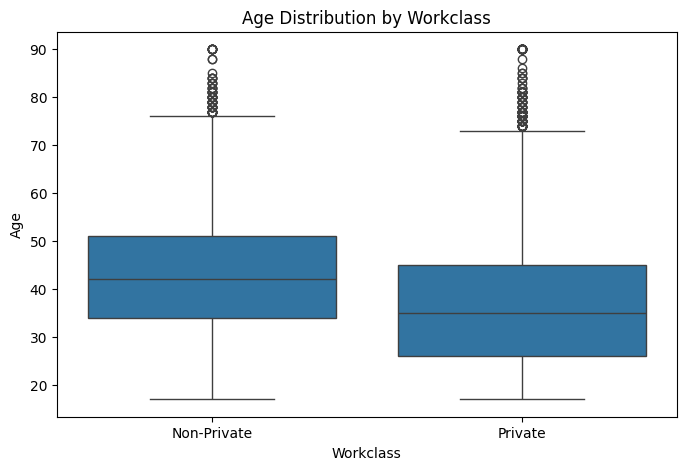

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="workclass_binary",
    y="age"
)

plt.xticks(
    [0, 1],
    ["Non-Private", "Private"]
)

plt.title("Age Distribution by Workclass")
plt.xlabel("Workclass")
plt.ylabel("Age")

plt.show()

HOURS-PER-WEEK VS WORKCLASS

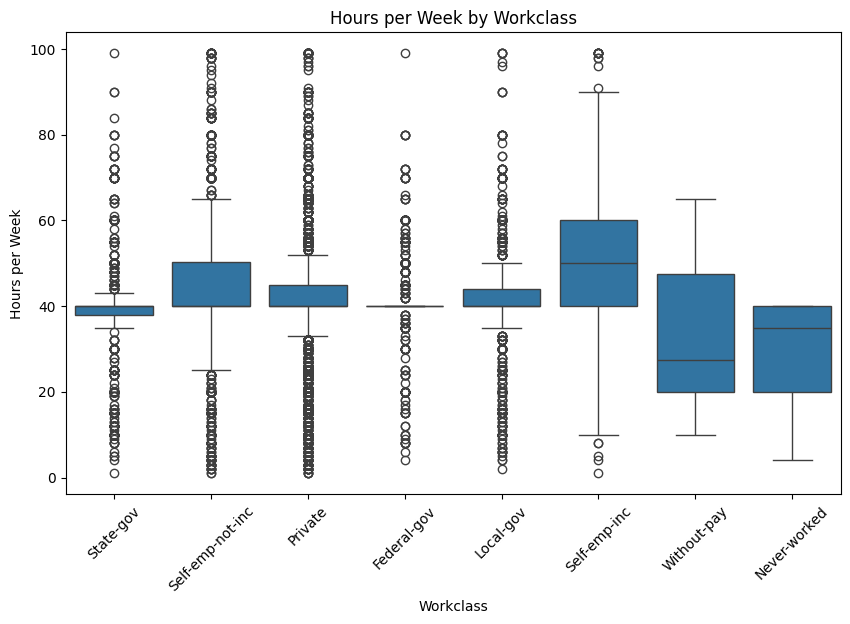

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="workclass",
    y="hours-per-week"
)

plt.title("Hours per Week by Workclass")
plt.xlabel("Workclass")
plt.ylabel("Hours per Week")

plt.xticks(rotation=45)

plt.show()

Create  target

In [ ]:
y = df["workclass_binary"]

In [ ]:
features = [
    "age",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "hours-per-week",
    "native-country"
]

X = df[features]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (24580, 10)
Testing set: (6145, 10)


In [ ]:
numeric_features = [
    "age",
    "education-num",
    "hours-per-week"
]

categorical_features = [
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

COLUMN TRANSFORMER

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

--Classification
La régression logistique est utilisée pour prédire une variable binaire : Private ou Non-Private.

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000
        ))
    ]
)

logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)

In [ ]:
print("Logistic Regression")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1-score:",
    f1_score(y_test, y_pred_lr)
)

Logistic Regression
--------------------
Accuracy: 0.7672904800650936
Precision: 0.7818676337262013
Recall: 0.9499889843577881
F1-score: 0.8577680525164114


Decision Tree

In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [ ]:
print("Decision Tree")
print("-------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_tree)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_tree)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_tree)
)

print(
    "F1-score:",
    f1_score(y_test, y_pred_tree)
)

Decision Tree
-------------
Accuracy: 0.7656631407648494
Precision: 0.7769436997319035
Recall: 0.9576999339061467
F1-score: 0.8579040852575488


Random Forest

```
 combine plusieurs Decision Trees afin d'obtenir une prédiction plus robuste
```



In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Random Forest")
print("-------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1-score:",
    f1_score(y_test, y_pred_rf)
)

Random Forest
-------------
Accuracy: 0.7658258746948738
Precision: 0.7677954388389772
Recall: 0.9790702797973122
F1-score: 0.8606565314224848


Comparer les 3 modèles

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.767290,0.781868,0.949989,0.857768
1,Decision Tree,0.765663,0.776944,0.957700,0.857904
2,Random Forest,0.765826,0.767795,0.979070,0.860657


meilleur modèle

In [ ]:
best_model = results.loc[
    results["F1-score"].idxmax()
]

best_model

,2
Model,Random Forest
Accuracy,0.765826
Precision,0.767795
Recall,0.97907
F1-score,0.860657


Confusion Matrix

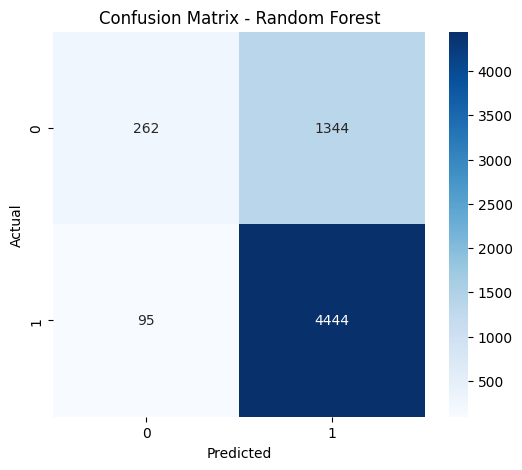

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Non-Private",
            "Private"
        ]
    )
)

              precision    recall  f1-score   support

 Non-Private       0.73      0.16      0.27      1606
     Private       0.77      0.98      0.86      4539

    accuracy                           0.77      6145
   macro avg       0.75      0.57      0.56      6145
weighted avg       0.76      0.77      0.71      6145



FEATURE IMPORTANCE

Which characteristics are the most useful for predicting workclass?

In [ ]:
rf_preprocessor = rf_model.named_steps["preprocessing"]

feature_names = (
    numeric_features +
    list(
        rf_preprocessor
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

In [ ]:
importances = (
    rf_model
    .named_steps["classifier"]
    .feature_importances_
)

In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
0,age,0.166560
37,occupation_Protective-serv,0.095385
2,hours-per-week,0.091902
1,education-num,0.079507
36,occupation_Prof-specialty,0.076264
33,occupation_Machine-op-inspct,0.063132
31,occupation_Farming-fishing,0.056679
23,marital-status_Never-married,0.035928
41,relationship_Husband,0.023854
21,marital-status_Married-civ-spouse,0.023079


Graph Feature Importance

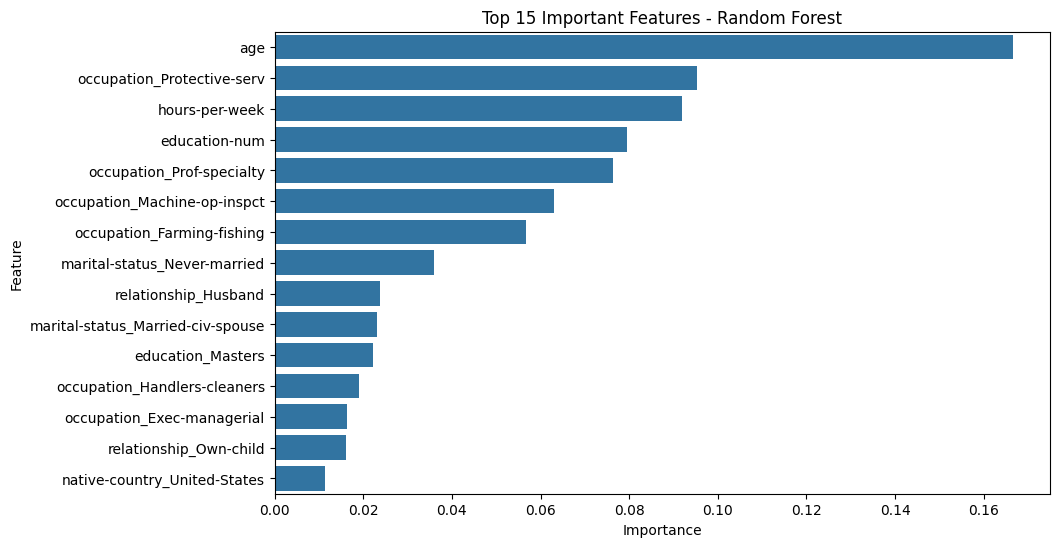

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

SAUVEGARDE

In [ ]:
prepared_df = df.copy()

prepared_df.to_csv(
    "adult_employment_prepared.csv",
    index=False
)

print("Prepared dataset saved successfully!")
print(
    "Shape:",
    prepared_df.shape
)

Prepared dataset saved successfully!
Shape: (30701, 16)


In [ ]:
from google.colab import files

files.download(
    "adult_employment_prepared.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>